# Run Comparison
This notebook is used in order to compare SEM2DPACK runs

## 1) Import data

### Libraries

In [5]:
#import libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# Set up matplotlib parameters
plt.rcParams['figure.dpi'] = 150
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

# Add the parent directory and modules directory to the system path
sys.path.append(os.getcwd()+'/../')
sys.path.append(os.getcwd()+'/../modules')

# Import custom modules
from Class_sem2dpack import *
from Stage_module import *

### User Parameters

In [6]:
#--------------------------------------------------
#                 USER PARAMETERS
#--------------------------------------------------

# SEM2DPACK Parameters
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Test_f_20"
direct2 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Essai_Gravity"
direct3 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Essai_Gravity_Low"
is_overburden = False
fmin, fmax = 0.01, 100
SEM1 = sem2dpack(direct1)
SEM2 = sem2dpack(direct2)
SEM3 = sem2dpack(direct3)


# Notebook Parameters
save_figure = False


#--------------------------------------------------

Reading grid information...
Reading header file...
0.001 5001 2890
--- No extra station ---
*
Reading grid information...
Reading header file...
0.001 20001 2890
--- No extra station ---
*
Reading grid information...
Reading header file...
0.001 20001 2890
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

### Fault Data

In [7]:
# Vector orientations for fault components
vector_orientations = {}
vector_orientations['Left'] = -1, -1
vector_orientations['Bottom'] = -1, +1
vector_orientations['Right'] = +1, +1


# Function to process fault data for a given SEM object
def process_fault_data(SEM):
    fault_data = {}
    
    # Read fault data for different tags
    read_fault_testing(SEM, ftag=5)
    fault_data['Bottom'] = SEM.fault

    read_fault_testing(SEM, ftag=7)
    fault_data['Right'] = SEM.fault

    read_fault_testing(SEM, ftag=9)
    fault_data['Left'] = SEM.fault

    # Extract the coordinates and slip values for each fault component
    fault_components = {}
    for key, data in fault_data.items():
        X_coord = data['x']
        Z_coord = data['z']
        Slip_1 = data['Slip_1']
        Slip_2 = data['Slip_2']
        orientation = 'Z' if key in ['Left', 'Right'] else 'X'
        Peak_Sliding = np.max( np.max(np.abs(Slip_1), axis=1) )
        Peak_Uplift = np.max( np.max(np.abs(Slip_2), axis=1) )
        fault_components[key] = {
            'X_coord': X_coord, 
            'Z_coord': Z_coord,
            'Slip_1': Slip_1,
            'Slip_2': Slip_2,
            'orientation': orientation,
            'Peak_Sliding': Peak_Sliding,
            'Peak_Uplift': Peak_Uplift
            }
        

    # Extract the time data (assuming it's the same for all components)
    time_fault = fault_data['Left']['Time']

    return fault_components, time_fault

# Process fault data for SEM1 and SEM2
fault_components_SEM1, time_fault_SEM1 = process_fault_data(SEM1)
fault_components_SEM2, time_fault_SEM2 = process_fault_data(SEM2)
fault_components_SEM3, time_fault_SEM3 = process_fault_data(SEM3)



DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Norma

### Stations data

In [8]:
def create_path(SEM,comp,t):
        n = f"{t:03d}"
        path = SEM.directory + f'v{comp}_{n}_sem2d.dat'
        return path

def load_field(SEM, comp, t):
    X_Coord, Z_Coord = SEM.mdict["coord"][:,0] , SEM.mdict["coord"][:,1]
    path = create_path(SEM,comp, t)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File {path} does not exist.")
    field = SEM.readField(path)
    return X_Coord, Z_Coord, field

def process_station_data(SEM):
    # Read Input Signal
    input_signal_path = SEM.directory+'/source'
    input_signal = np.genfromtxt(open(input_signal_path,'r'))
    time_input = input_signal[:,0]
    V_input = input_signal[:,1]

    # Read the X component of stations data
    SEM.read_seismo('x')
    SEM.filter_seismo(fmin, fmax)
    Time_stations = SEM.time
    Vx = SEM.velocity[:,:]
    Ux = np.zeros(Vx.shape, dtype=np.float32)
    Ax = np.zeros(Vx.shape, dtype=np.float32)
    for i in range(Vx.shape[1]):
        V = Vx[:,i]
        Ux[:,i] = compute_displacement(V, Time_stations)
        Ax[:,i] = compute_acceleration(V, Time_stations)
        

    # Read the Z component of stations data
    SEM.read_seismo('z')
    SEM.filter_seismo(fmin, fmax)
    Vz = SEM.velocity[:,:]
    Uz = np.zeros(Vz.shape, dtype=np.float32)
    Az = np.zeros(Vz.shape, dtype=np.float32)
    for i in range(Vz.shape[1]):
        V = Vz[:,i]
        Uz[:,i] = compute_displacement(V, Time_stations)
        Az[:,i] = compute_acceleration(V, Time_stations)

    # Read stations coordinates
    XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]

    # Read Snapshots data
    # for i in range(0,1000):
    #     try : 
    #         if i==0:
    #             X_snap, Z_snap, Vx_snap = load_field(SEM, 'x', i)
    #             _, _, Vz_snap = load_field(SEM, 'z', i)
    #             Vx_snap = np.expand_dims(Vx_snap, axis=1)
    #             Vz_snap = np.expand_dims(Vz_snap, axis=1)
    #         else :
    #             _, _, Vx_temp = load_field(SEM, 'x', i)
    #             _, _, Vz_temp = load_field(SEM, 'z', i)
    #             Vx_snap = np.concatenate([Vx_snap, np.expand_dims(Vx_temp, axis=1)], axis=1)
    #             Vz_snap = np.concatenate([Vz_snap, np.expand_dims(Vz_temp, axis=1)], axis=1)
    #     except FileNotFoundError:
    #         break


    # Compute PGD, PGV and PGA
    PGDx = np.max(np.abs(Ux), axis=0)
    PGDz = np.max(np.abs(Uz), axis=0)
    PGVx = np.max(np.abs(Vx), axis=0)
    PGVz = np.max(np.abs(Vz), axis=0)
    PGAx = np.max(np.abs(Ax), axis=0)
    PGAz = np.max(np.abs(Az), axis=0)
    

    # Create a dictionary to hold the components of the stations data
    components = {}
    components['time_input'] = time_input
    components['V_input'] = V_input
    components['X'] = XSTA
    components['Z'] = ZSTA
    components['Ux'] = Ux
    components['Uz'] = Uz
    components['Vx'] = Vx
    components['Vz'] = Vz
    components['Ax'] = Ax
    components['Az'] = Az
    components['PGDx'] = PGDx
    components['PGDz'] = PGDz
    components['PGVx'] = PGVx
    components['PGVz'] = PGVz
    components['PGAx'] = PGAx
    components['PGAz'] = PGAz
    # components['X_snap'] = X_snap
    # components['Z_snap'] = Z_snap
    # components['Vx_snap'] = Vx_snap
    # components['Vz_snap'] = Vz_snap
    return components, Time_stations

station_components_SEM1, time_stations_SEM1 = process_station_data(SEM1)
station_components_SEM2, time_stations_SEM2 = process_station_data(SEM2)
station_components_SEM3, time_stations_SEM3 = process_station_data(SEM3)



Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...


### Grid Data

In [9]:
def process_grid_data(SEM):
    SEM_grid = import_SEM_grid(SEM.directory)
    print("Grid data processed for SEM:", SEM.directory)
    X = SEM_grid['X']
    Z = SEM_grid['Z']
    Vs = SEM_grid['Vs']
    return SEM_grid


# Process grid data for SEM1, SEM2
grid_data_SEM1 = process_grid_data(SEM1)
grid_data_SEM2 = process_grid_data(SEM2)
grid_data_SEM3 = process_grid_data(SEM3)



(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Test_f_20/
(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Essai_Gravity/
(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Essai_Gravity_Low/


## 2) Visualization

### Input Signal

500
100


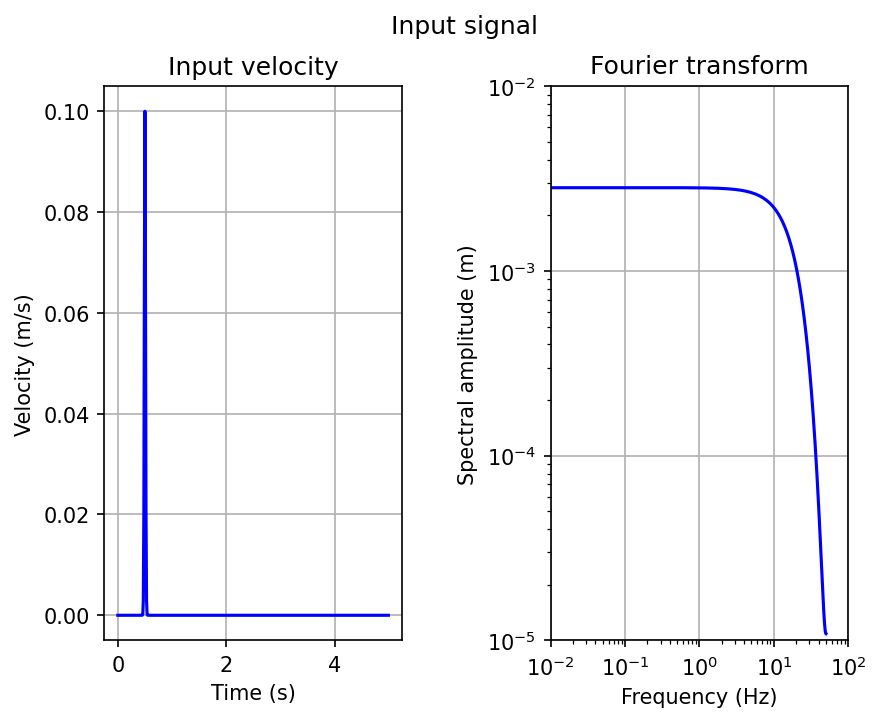

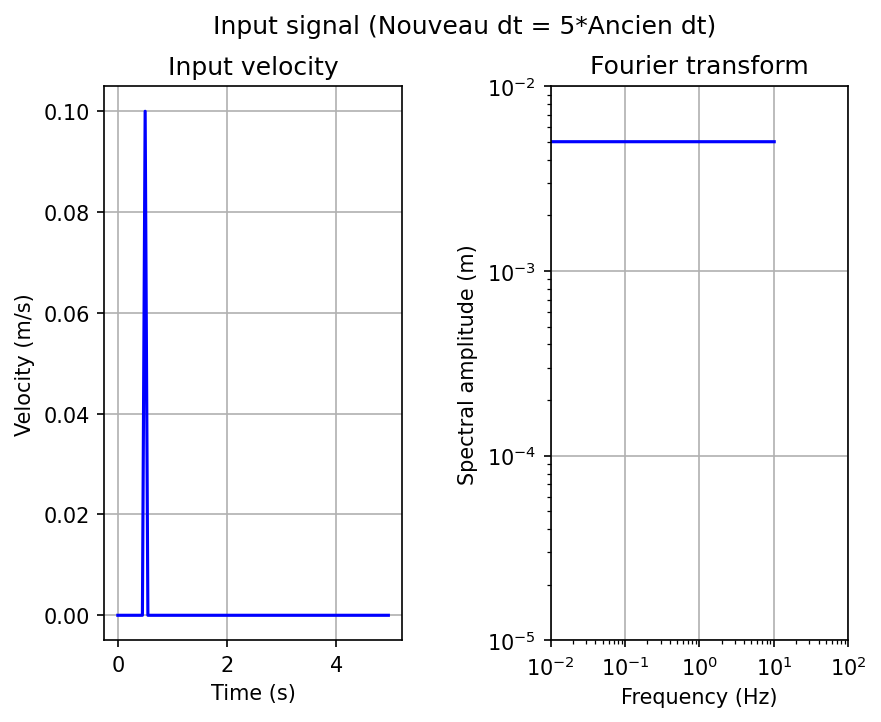

In [34]:
plot_input_signal(station_components_SEM1['time_input'], station_components_SEM1['V_input'], 'VF', fmax=fmax, Amax=1e-2)
decalage = 5
print(station_components_SEM1['time_input'].size)
print(station_components_SEM1['time_input'][::decalage].size)
plot_input_signal(station_components_SEM1['time_input'][::decalage], station_components_SEM1['V_input'][::decalage], 'VF', fmax=fmax, Amax=1e-2)
plt.suptitle(f"Input signal (Nouveau dt = {decalage}*Ancien dt)")
plt.show()


### Stations

In [11]:
def show_stations(stations_components):
    """
    Function to draw the stations on a plot.
    
    Parameters:
    stations_components (dict): Dictionary containing the station components.
    """
    # Draw the plot
    XSTA, ZSTA = stations_components['X'], stations_components['Z']
    fig, ax = plt.subplots()
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.scatter(XSTA, ZSTA, marker='v')
    ax.set_title("Drawing of the stations")


#show_stations(station_components_SEM3)

### Soil Properties Visualization

In [12]:
# visualize_grid(grid_data_SEM1, component='Vs')
# visualize_grid(grid_data_SEM2, component='Vs')
# visualize_grid(grid_data_SEM3, component='Vs')
# compute_soil_mean(grid_data_SEM1, 100, component='Vs')
# compute_soil_mean(grid_data_SEM2, 100, component='Vs')
# compute_soil_mean(grid_data_SEM3, 100, component='Vs')

# plt.show()

### Fourier 2D Spectrum

In [13]:
def compute_Fourier_2D(grid_data, comp):
    
    #Read grid data
    X, Z = grid_data['X'], grid_data['Z']
    soil_mask = (Z <= 0)
    structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
    mask = soil_mask & ~structure_mask
    X, Z, val = grid_data['X'][mask], grid_data['Z'][mask], grid_data[comp][mask]

    # Compute the Fourier Transform
    Lx, Lz = np.max(X)-np.min(X), np.max(Z)-np.min(Z)
    Nx,Nz = int(2*Lx), int(2*Lz)
    kx, kz = compute_spatial_frequencies(Lx, Lz, Nx, Nz)

    X_mesh, Z_mesh = np.linspace(X.min(), X.max(), Nx), np.linspace(Z.min(), Z.max(), Nz)
    X_mesh, Z_mesh = np.meshgrid(X_mesh, Z_mesh)
    val_interp = griddata((X,Z), val, (X_mesh, Z_mesh), method='linear')
    F = np.fft.fft2(val_interp)
    F_abs = np.abs(F)

    # Plot the Fourier Transform
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect(None, zoom=0.8)
    Kx, Kz = np.meshgrid(kx, kz)
    ax.plot_trisurf(Kx.flatten(),Kz.flatten(), np.log(F_abs.flatten()), cmap='viridis')
    ax.set_xlabel('kx (1/m)')
    ax.set_ylabel('kz (1/m)')
    ax.set_zlabel('log(Fourier Amplitude)')
    ax.set_title('Fourier Transform of the grid')
    plt.show()

#compute_Fourier_2D(grid_data_SEM1, 'Vs')
# compute_Fourier_2D(grid_data_SEM2, 'Vs')




## 3) Post-Processing

### Compare Stations

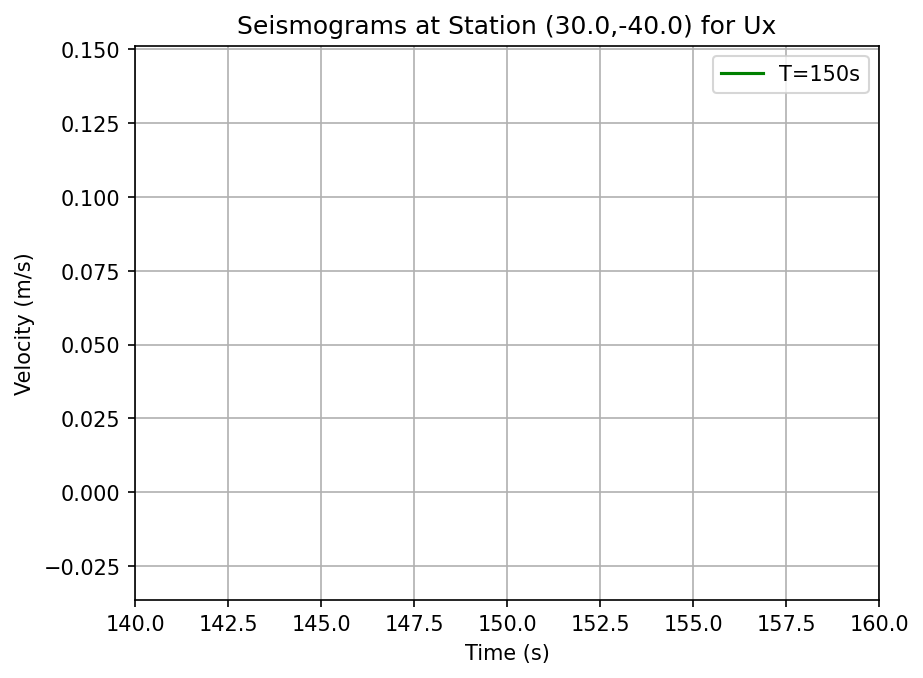

In [14]:
def plot_seismogram(ax, station, comp, time_station, station_components, color='blue', label=None):
    try :
        val = station_components[comp]
    except KeyError:
        raise Exception('Not a valid component')
    ax.plot(time_station, val[:,station], color=color, label=label)



comp = 'Vx'

fig, ax = plt.subplots()
station = get_nearest_station(30,-40,station_components_SEM3['X'], station_components_SEM3['Z'])
# plot_seismogram(ax, station, comp, time_stations_SEM1, station_components_SEM1, color='blue', label='T=50s')
# plot_seismogram(ax, station, comp, time_stations_SEM2, station_components_SEM2, color='red', label='T=100s')
plot_seismogram(ax, station, comp, time_stations_SEM3, station_components_SEM3, color='green', label='T=150s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (m/s)')
ax.set_title(f'Seismograms at Station ({station_components_SEM3['X'][station]},{station_components_SEM3['Z'][station]}) for Ux')
ax.legend()
ax.grid(True)
ax.set_xlim(140,160)
# ax.set_ylim(-1e-6,1e-6)
plt.show()

### Compare Interface

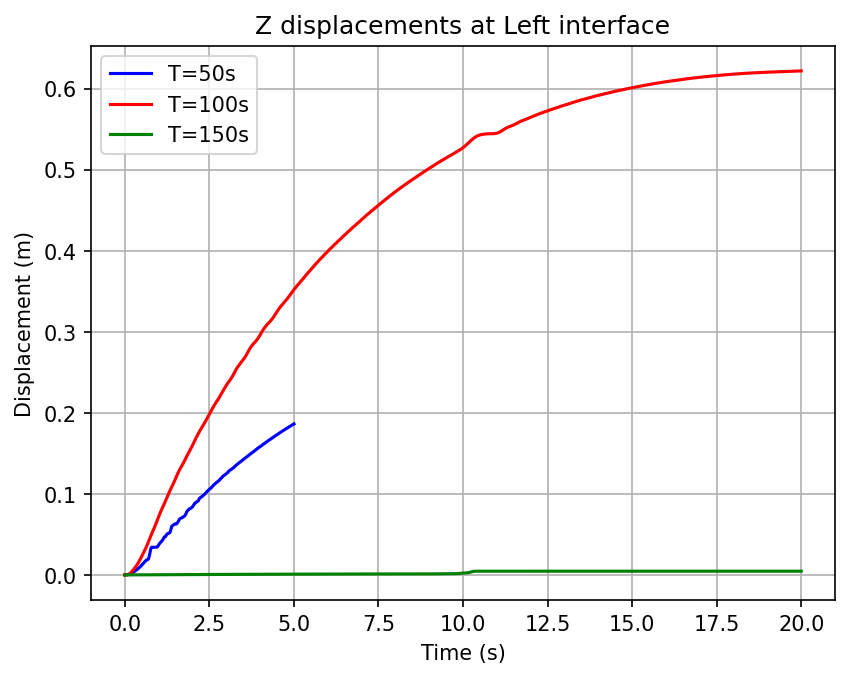

In [15]:

def plot_interface(ax, interface, comp, station, time_fault, fault_components, color='blue', label=None):
    Slip_1 = fault_components[interface]['Slip_1']
    Slip_2 = fault_components[interface]['Slip_2']
    orientation = fault_components[interface]['orientation']
    if orientation == comp:
        ax.plot(time_fault, Slip_1[station,:], color=color, label=label)
    else:
        ax.plot(time_fault, Slip_2[station,:], color=color, label=label)

    ax.set_title(f'{comp} displacements at {interface} interface')

fig, ax = plt.subplots()
station = 7
interf = 'Left'
comp = 'Z'
plot_interface(ax, interf, comp, station, time_fault_SEM1, fault_components_SEM1, color='blue', label='T=50s')
plot_interface(ax, interf, comp, station, time_fault_SEM2, fault_components_SEM2, color='red', label='T=100s')
plot_interface(ax, interf, comp, station, time_fault_SEM3, fault_components_SEM3, color='green', label='T=150s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement (m)')
ax.legend()
ax.grid(True)
plt.show()

### Compare PGA and PGV

(8,)


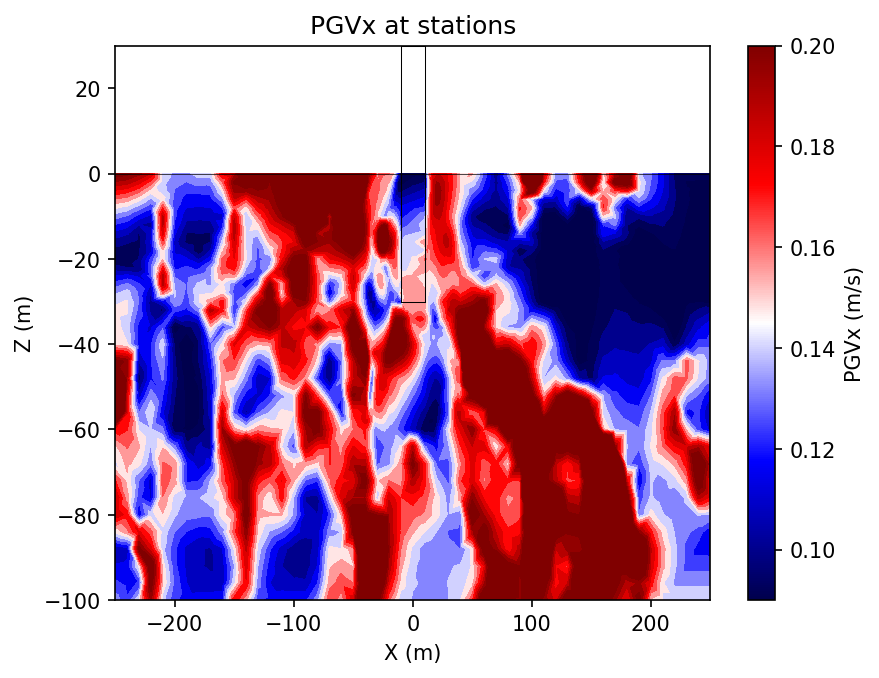

(8,)


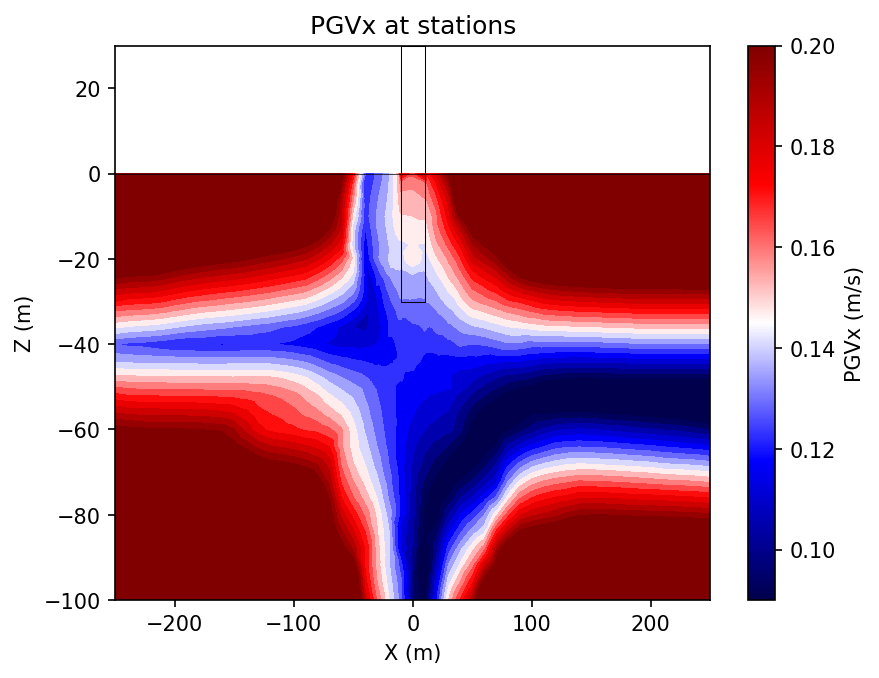

(8,)


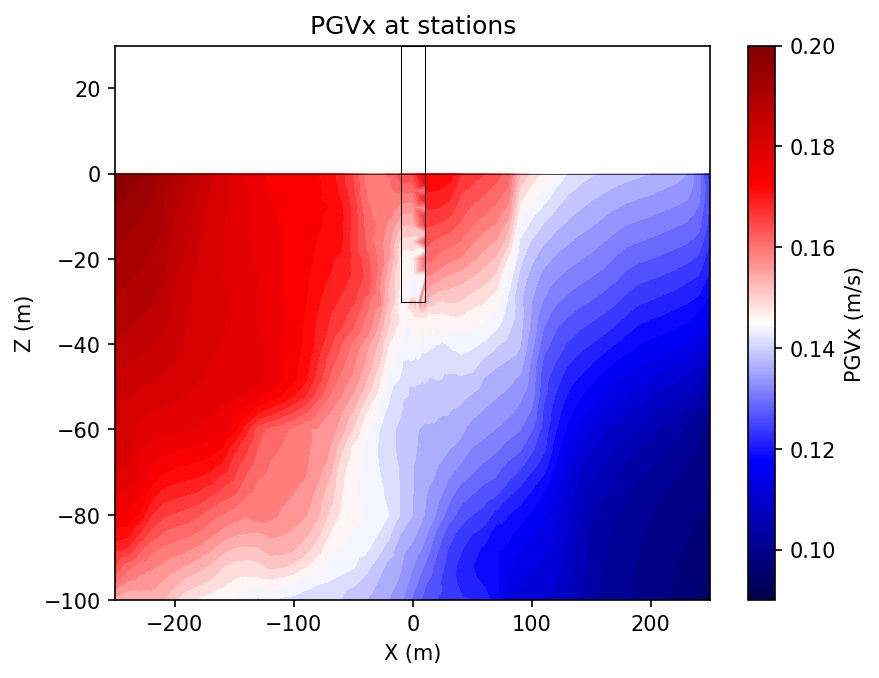

In [16]:
def plot_peak_values(station_components, comp, norm=None):
    if comp not in ['PGVx', 'PGVz', 'PGAx', 'PGAz']:
        raise Exception('Not a valid component for peak values')
    fig, ax = plt.subplots()
    cmap = 'seismic'
    X = station_components['X']
    Z = station_components['Z']
    soil_mask = (Z <= 0)
    structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
    print(X[structure_mask].shape)
    #ax.tricontourf(X[structure_mask], Z[structure_mask], station_components[comp][structure_mask], levels=50, cmap=cmap, norm=norm)
    ax.tricontourf(X[soil_mask], Z[soil_mask], station_components[comp][soil_mask], levels=50, cmap=cmap, norm=norm)
    #ax.fill([-10,10,10,-10],[-30,-30,30,30], color='white')
    if norm is None:
        norm = plt.Normalize(vmin=np.min(station_components[comp]), vmax= np.max(station_components[comp]))
    fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax, label='PGVx (m/s)')
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.set_title(f'{comp} at stations')
    plt.show()

comp = 'PGVx'
norm = plt.Normalize(vmin=0.09, vmax=0.2)
#norm=None
plot_peak_values(station_components_SEM1, comp, norm=norm)
plot_peak_values(station_components_SEM2, comp, norm=norm)
plot_peak_values(station_components_SEM3, comp, norm=norm)

### Compare deformed structure

NameError: name 'fault_components_SEM4' is not defined

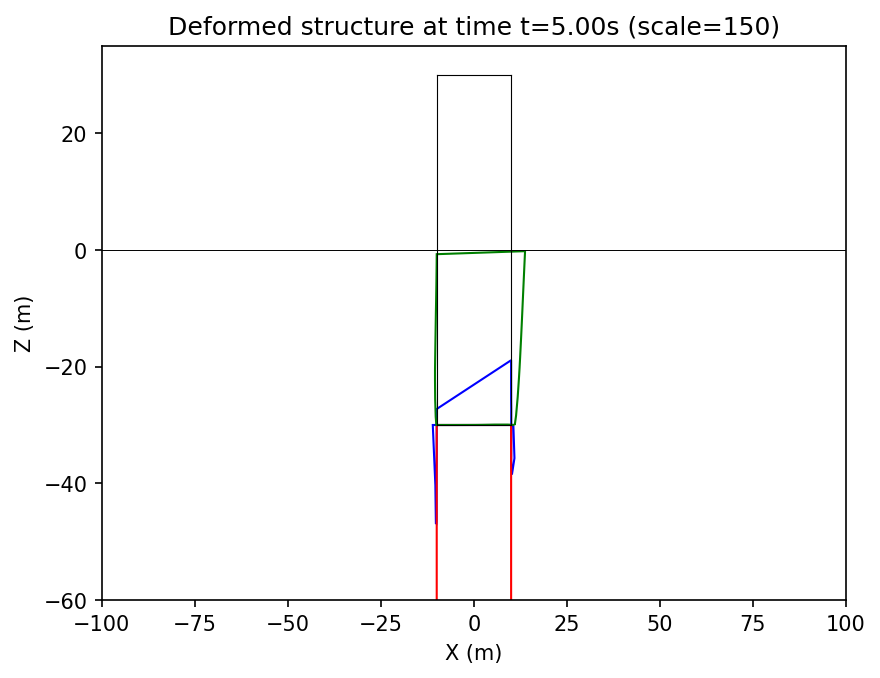

In [17]:

def compute_disp_fault(t, comp, fault_components):
    X_comp = np.array([])
    Z_comp = np.array([])
    Slip_1 = fault_components[comp]['Slip_1']
    Slip_2 = fault_components[comp]['Slip_2']
    S1_dir = fault_components[comp]['orientation']
    if S1_dir=='X':
        X_add = vector_orientations[comp][0]*Slip_1[:,t]
        Z_add= vector_orientations[comp][1]*Slip_2[:,t]
    else :
        X_add = vector_orientations[comp][0]*Slip_2[:,t]
        Z_add = vector_orientations[comp][1]*Slip_1[:,t]
    
    X_comp = np.concatenate([X_comp, X_add])
    Z_comp = np.concatenate([Z_comp, Z_add])
    return X_comp, Z_comp

def compute_deformation(t, scale, fault_components):
    X_coord, Z_coord = np.array([]), np.array([])
    X_comp, Z_comp = np.array([]), np.array([])
    X_new, Z_new = np.array([]), np.array([])
    for c in fault_components.keys():
        X_coord_c = fault_components[c]['X_coord']
        Z_coord_c = fault_components[c]['Z_coord']
        X_comp_c, Z_comp_c = compute_disp_fault(t, c, fault_components)
        X_new_c = X_coord_c + scale*X_comp_c
        Z_new_c = Z_coord_c + scale*Z_comp_c
        if c=="Left":
            X_new_c = np.flip(X_new_c)
            Z_new_c = np.flip(Z_new_c)
        X_coord = np.concatenate([X_coord, X_coord_c])
        Z_coord = np.concatenate([Z_coord, Z_coord_c])
        X_comp = np.concatenate([X_comp, X_comp_c])
        Z_comp = np.concatenate([Z_comp, Z_comp_c])
        X_new = np.concatenate([X_new, X_new_c])
        Z_new = np.concatenate([Z_new, Z_new_c])
    return X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new

def draw_fault_deformation(t, ax, fault_components, scale=100, color='red', label=None):
    time = time_fault_SEM1[t]
    ax.set_title(f"Deformed structure at time t={time:.2f}s (scale={scale:.0f})")
    draw_example(ax)
    X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new = compute_deformation(t, scale, fault_components)
    #ax.quiver(X_coord, Z_coord, X_comp, Z_comp, scale=1/scale, scale_units='xy', angles='xy')
    ax.fill(X_new, Z_new, facecolor='none', edgecolor=color, label=label)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
draw_fault_deformation(-1, ax, fault_components_SEM1,scale=150, color='blue', label="SEM1")
draw_fault_deformation(-1, ax, fault_components_SEM2,scale=150, color='red', label="SEM2")
draw_fault_deformation(-1, ax, fault_components_SEM3,scale=150, color='green', label="SEM3")
draw_fault_deformation(-1, ax, fault_components_SEM4,scale=150, color='violet', label="SEM4")
ax.legend()
ax.set_xlim([-20,20])
ax.set_ylim([-40,35])
plt.show()

### Deformed Structure Animation

In [ ]:
fig, ax = plt.subplots()

def animate(t):
    ax.cla()
    scale = 150
    draw_fault_deformation(t, ax, fault_components_SEM1, scale=scale, color='blue', label="SEM1")
    draw_fault_deformation(t, ax, fault_components_SEM2, scale=scale, color='red', label="SEM2")
    draw_fault_deformation(t, ax, fault_components_SEM3,scale=150, color='green', label="SEM3")
    ax.legend()
    ax.set_xlim([-20,20])
    ax.set_ylim([-40,35])


anim.FuncAnimation(fig, animate, np.arange(0, len(time_fault_SEM1),5000))

### Field animation

In [ ]:
# Functions definition
def create_path(SEM,comp,t):
    n = f"{t:03d}"
    path = SEM.directory + f'v{comp}_{n}_sem2d.dat'
    return path

def load_field(SEM, comp, t):
    X_Coord, Z_Coord = SEM.mdict["coord"][:,0] , SEM.mdict["coord"][:,1]
    path = create_path(SEM,comp, t)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File {path} does not exist.")
    field = SEM.readField(path)
    return X_Coord, Z_Coord, field

    



In [ ]:
#fig, [ax1, ax2, ax3] = plt.subplots(1,3, figsize=(15,5))
fig = plt.figure()
gs = plt.GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
station_components = station_components_SEM1
time_stations = time_stations_SEM1
comp = 'Vx'
max_val = 0.1
norm = plt.Normalize(vmin=-max_val, vmax=max_val)
cmap = 'seismic'
# cbar = fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax3, label=f'{comp}')
cbar = fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax3, label=f'{comp}')



indic = 'log'



def plot_field(ax,X,Z,field):
    #ax.cla()
    norm = plt.Normalize(vmin=np.min(field), vmax= np.max(field))
    ax.tricontourf(X, Z, field, levels=50, cmap=cmap, norm=norm)
    ax.fill([-10,10,10,-10],[-30,-30,30,30], color='silver')
    cbar.update_normal(ScalarMappable(norm=norm,cmap=cmap))
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.set_title(f'{comp} in the ISS example')
    plt.show()

def compute_log_ratio(val1, val2):
    epsilon = 1e-6
    ratio = np.log10(val1/val2)
    return np.nan_to_num(ratio, nan=0.0, posinf=max_val, neginf=-max_val)

def compute_relative_difference(val1, val2):
    epsilon = 1e-6
    return np.nan_to_num(np.abs((val1 - val2) / (val2 + epsilon)), nan=0.0, posinf=max_val, neginf=0.0)

def compute_relative_difference_test(val1, val2):
    epsilon = 1e-4
    return np.log10((val1 + epsilon) / (val2 + epsilon) + epsilon)

def animate_field(t, station_components, comp):
    ax3.cla()
    ax3.set_facecolor('silver')
    X, Z, field = station_components['X'], station_components['Z'], station_components[comp][t,:]
    soil_mask = (Z <= 0)
    structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
    plot_field(ax3, X[soil_mask], Z[soil_mask], field[soil_mask])
    #plot_field(ax3, X[structure_mask], Z[structure_mask], field[structure_mask])
    fig.tight_layout()

visualize_grid(grid_data_SEM2, component='Vs', ax=ax1)
visualize_grid(grid_data_SEM3, component='Vs', ax=ax2)
fig.tight_layout()
# def animate_diff(t):
#     ax3.cla()
#     ax3.set_facecolor('silver')
#     X, Z, Vx_1 = load_field(SEM2, 'x', t)
#     _, _, Vx_2 = load_field(SEM3, 'x', t)
#     ratio = compute_log_ratio(Vx_1, Vx_2)
#     diff = compute_relative_difference_test(Vx_1, Vx_2)
#     mask = np.isnan(ratio) | np.isinf(ratio)
#     X, Z, ratio = X[~mask], Z[~mask], ratio[~mask]
#     comp = ratio
#     soil_mask = (Z <= 0)
#     structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
#     plot_field(ax3, X[soil_mask], Z[soil_mask], comp[soil_mask])
#     plot_field(ax3, X[structure_mask], Z[structure_mask], comp[structure_mask])
#     fig.tight_layout()
    

anim.FuncAnimation(fig, lambda t : animate_field(t, station_components_SEM4, 'Vx'), np.arange(0, 20000, 100))